In [ ]:
# Run this setup only in Google Colab
import os
import subprocess
import sys

try:
    from google.colab import drive
    drive.mount("/content/drive")
    os.chdir("/content/drive/MyDrive/Colab Notebooks/ml2_trabalhos_2026")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", ".", "--no-deps"])
except ModuleNotFoundError:
    print("Not running in Colab; skipping Drive mount and install steps.")

# Trabalho 3 — Marcas d’Água em Dados para Auditoria de Modelos Generativos

> **Pergunta central:** como podemos marcar um conjunto de dados de forma que, se ele for usado no treinamento de um modelo generativo, seja possível auditar posteriormente esse uso?

Neste trabalho usaremos **Variational Autoencoder** como nosso método generativo base, e investigaremos estratégias para **auditoria de uso de dados em modelos generativos**. A situação é a seguinte: o dono de uma base de dados disponibiliza um conjunto de imagens, mas quer preservar a capacidade de verificar, posteriormente, se essas imagens foram usadas por terceiros no treinamento de um modelo generativo.

Para isso, vamos estudar a ideia de inserir uma **marca d’água nos dados de treino**.
Vamos fazer esse estudo usando os dados do MNIST.

Exploraremos duas estratégias:
1. **Marca visível** — patch fixo no canto da imagem. Fácil de detectar, trivialmente removível.
2. **Marca spread-spectrum** — textura pseudo-aleatória de baixa amplitude. Idealmente imperceptível ao olho, detectável via correlação com a chave secreta.

E faremos um **estudo de ablação** variando amplitude, fração marcada e o número de amostras usadas para a auditoria.

**Entregáveis.**
1. Notebook preenchido e executado.
2. Pesos dos VAEs treinados (limpo, marca visível, marca spread-spectrum).
3. Respostas das questões com evidências numéricas dos seus próprios resultados.

**Regras.** Use PyTorch. Fixe seeds. Não apague células do enunciado.

## Parte 0 — Setup e reprodutibilidade

**Tarefa 0.1.** Fixe as seeds aleatórias e configure o dispositivo.

**Tarefa 0.2.** Imprima as versões de `torch` e `torchvision`.

**Tarefa 0.3.** Defina `student_run_tag` (suas iniciais + data) — use ao salvar artefatos.

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

SEED       = 42    # semente do experimentador: splits, pesos, etc.
OWNER_SEED = 1234  # semente do dono dos dados: gera o padrão secreto

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
print(f"Torch: {torch.__version__}  |  Torchvision: {__import__('torchvision').__version__}")

student_run_tag = "Heri_Version_2026-05-26"   # ex: "DA_2026-05-22"
output_dir = Path("trabalho3_outputs") / student_run_tag
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output dir: {output_dir}")

Dispositivo: cuda
Torch: 2.7.1+cu118  |  Torchvision: 0.22.1+cu118
Output dir: trabalho3_outputs/Heri_Version_2026-05-26


In [2]:
student_run_tag = "Heri_Version_2026-05-29"   # ex: "DA_2026-05-22"
output_dir = Path("trabalho3_outputs") / student_run_tag
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output dir: {output_dir}")

Output dir: trabalho3_outputs/Heri_Version_2026-05-29


## Parte 1 — VAE no MNIST

Antes de pensar em marca d'água, precisamos de um modelo generativo razoável. Vamos construir um VAE simples no MNIST.

### 1.1 Dados

**Tarefa 1.1.** Carregue o MNIST de treino e teste com `torchvision.datasets.MNIST` (transformação: apenas `ToTensor()`).

In [2]:
transform = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.MNIST(root="./data_heri_3", 
                          train=True, 
                          download=True, 
                          transform=transform)    # TODO
test_ds  = datasets.MNIST(root="./data_heri_3", 
                          train=False, 
                          download=True, 
                          transform=transform)    # TODO

BATCH_SIZE = 256 # Esse é um hiperparâmetro que pode ser ajustado. Valores como 64, 128, 256, etc. para ver o impacto no treinamento.
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)  # TODO
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)  # TODO

print(f"Treino: {len(train_ds):,}  |  Teste: {len(test_ds):,}")

Treino: 60,000  |  Teste: 10,000


### 1.2 Arquitetura do VAE

Um VAE é composto por:
- **Encoder** $q_\phi(z \mid x)$: projeta a imagem no espaço latente, produzindo $\mu$ e $\log\sigma^2$.
- **Reparametrização**: $z = \mu + \sigma \odot \epsilon$, $\epsilon \sim \mathcal{N}(0, I)$.
- **Decoder** $p_\theta(x \mid z)$: reconstrói a imagem a partir de $z$ (saída em $[0,1]$ via sigmoid).

**Tarefa 1.2.** Implemente `Encoder`, `Decoder`, `VAE`. Use uma MLP simples (camadas escondidas de 512 e 256 unidades com ReLU). A dimensão latente (`LATENT_DIM`) é um hiperparâmetro configurável — para MNIST, valores entre 2 e 32 produzem modelos razoáveis.

In [3]:
IMG_DIM = 28 * 28

class Encoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(IMG_DIM, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )
        # TODO: definir self.fc_mu e self.fc_log_var (256 → latent_dim)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_log_var = nn.Linear(256, latent_dim)

    def forward(self, x):
        # TODO: achatar x, passar pela net, retornar (mu, log_var)
        x_flat = x.view(x.size(0), -1)        # Achatando a imagem para (batch_size, 784)
        hidden = self.net(x_flat)             # Passando pela rede
        mu = self.fc_mu(hidden)               # Calculando mu
        log_var = self.fc_log_var(hidden)     # Calculando log_var
        return mu, log_var                                                              


class Decoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, IMG_DIM),
            nn.Sigmoid()  # Para garantir que a saída esteja entre 0 e 1
        )                                                                                                           
        # TODO: definir self.net (Linear latent_dim→256→512→784 com ReLU; sigmoid no final)
        # raise NotImplementedError("Implemente Decoder.__init__")

    def forward(self, z):
        # TODO: aplicar self.net e reshape para (-1, 1, 28, 28)
        x_hat = self.net(z)                   # Passando o vetor latente pela rede
        x_hat = x_hat.view(-1, 1, 28, 28)     # Reshape para a forma da imagem
        return x_hat
        
        # raise NotImplementedError("Implemente Decoder.forward")

class VAE(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparametrize(self, mu, log_var):
        # TODO: implementar o truque da reparametrização
        std = torch.exp(0.5 * log_var)    # Calculando o desvio padrão a partir do log_var
        eps = torch.randn_like(std)       # Gera um ruído aleatório com a mesma forma de std
        z = mu + eps * std                # Aplica a reparametrização
        return z
        #raise NotImplementedError("Implemente reparametrize")

    def forward(self, x):
        # TODO: encode, sample, decode; retornar (x_hat, mu, log_var)
        mu, log_var = self.encoder(x)     # Passa a imagem pelo encoder para obter mu e log_var
        z = self.reparametrize(mu, log_var)  # Aplica o truque da reparametrização para obter o vetor latente z
        x_hat = self.decoder(z)        # Passa o vetor latente pelo decoder para obter a reconstrução da imagem
        return x_hat, mu, log_var      # Retorna a imagem reconstruída, mu e log_var    
        #raise NotImplementedError("Implemente VAE.forward")



In [4]:
LATENT_DIM = 8   # escolha um valor razoável (sugestão: entre 2 e 32 para MNIST)

model = VAE(LATENT_DIM).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"LATENT_DIM = {LATENT_DIM}  |  Parâmetros: {n_params:,}")

LATENT_DIM = 8  |  Parâmetros: 1,073,440


In [ ]:
LATENT_DIM = 16   # escolha um valor razoável (sugestão: entre 2 e 32 para MNIST)

model_a = VAE(LATENT_DIM).to(device)
n_params = sum(p.numel() for p in model_a.parameters() if p.requires_grad)
print(f"LATENT_DIM = {LATENT_DIM}  |  Parâmetros: {n_params:,}")

LATENT_DIM = 16  |  Parâmetros: 1,079,600


In [6]:
LATENT_DIM = 24   # escolha um valor razoável (sugestão: entre 2 e 32 para MNIST)

model_b = VAE(LATENT_DIM).to(device)
n_params = sum(p.numel() for p in model_b.parameters() if p.requires_grad)
print(f"LATENT_DIM = {LATENT_DIM}  |  Parâmetros: {n_params:,}")

LATENT_DIM = 24  |  Parâmetros: 1,085,760


### 1.3 Função de perda — ELBO

O VAE maximiza o **Evidence Lower Bound (ELBO)**:

$$\mathcal{L}(\theta, \phi; x) = \underbrace{\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x \mid z)]}_{\text{reconstrução}} - \underbrace{D_{KL}(q_\phi(z|x) \,\|\, p(z))}_{\text{regularização}}$$

Para imagens com pixels em $[0,1]$, usamos **BCE** (Bernoulli) como modelo de reconstrução. Como prior, $p(z) = \mathcal{N}(0, I)$, e a $\text{KL}$ tem forma fechada:

$$D_{KL}(q_\phi(z|x) \| \mathcal{N}(0,I)) = -\frac{1}{2}\sum_j \left(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$

**Tarefa 1.3.** Implemente `vae_loss` que retorna `(loss_total, recon, kl)`. Use BCE com `reduction="sum"` (some sobre pixels e batch).

In [5]:
def vae_loss(x, x_hat, mu, log_var):
    # TODO: BCE entre x_hat e x (reduction="sum")
    recon_loss = F.binary_cross_entropy(x_hat, x, reduction="sum")
    # TODO: KL fechada para prior N(0, I)
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    # TODO: retornar (loss_total, recon, kl)
    return recon_loss + kl_loss, recon_loss, kl_loss

### 1.4 Treinamento

Treine por **30 épocas** com Adam (lr=1e-3). A loss é a ELBO (somada sobre o batch, dividida no final por `len(dataset)` para reportar por amostra).

**Tarefa 1.4.** Implemente o loop de treino e salve o histórico de loss/recon/KL para treino e teste.

In [6]:
EPOCHS = 30
LR = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
history = {"train_loss": [], "train_recon": [], "train_kl": [],
           "test_loss":  [], "test_recon":  [], "test_kl":  []}


def run_epoch(loader, train: bool):
    # TODO: alternar entre model.train() / model.eval()  
    if train:
        model.train()           
    else:
        model.eval()    
    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0
    
    with torch.set_grad_enabled(train): # Habilita gradientes apenas se for treino
        for x, _ in loader:
            x = x.to(device)
            
            if train:
                optimizer.zero_grad()
            x_hat, mu, log_var = model(x)
            loss, recon, kl = vae_loss(x, x_hat, mu, log_var)
            
            if train:
                
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            total_recon += recon.item()
            total_kl += kl.item()

    num_samples = len(loader.dataset)
    avg_loss = total_loss / num_samples
    avg_recon = total_recon / num_samples
    avg_kl = total_kl / num_samples
    return avg_loss, avg_recon, avg_kl            

for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(train_loader, train=True)
    te = run_epoch(test_loader,  train=False)
    for key, value in zip(["loss", "recon", "kl"], tr):
        history[f"train_{key}"].append(value)
    for key, value in zip(["loss", "recon", "kl"], te):
        history[f"test_{key}"].append(value)
    #if epoch % 5 == 0 or epoch == 1:
    print(f"Ep {epoch:3d}/{EPOCHS} | tr loss {tr[0]:.2f}  recon {tr[1]:.2f}  kl {tr[2]:.2f} | te loss {te[0]:.2f}")

torch.save(model.state_dict(), output_dir / f"vae_clean_latent{LATENT_DIM}.pt")
print("Salvo.")

Ep   1/30 | tr loss 194.91  recon 190.17  kl 4.74 | te loss 151.16
Ep   2/30 | tr loss 138.14  recon 126.36  kl 11.79 | te loss 128.92
Ep   3/30 | tr loss 125.41  recon 111.82  kl 13.59 | te loss 120.39
Ep   4/30 | tr loss 119.24  recon 104.59  kl 14.65 | te loss 116.74
Ep   5/30 | tr loss 116.15  recon 101.06  kl 15.09 | te loss 114.44
Ep   6/30 | tr loss 114.17  recon 98.84  kl 15.33 | te loss 113.44
Ep   7/30 | tr loss 112.63  recon 97.15  kl 15.48 | te loss 111.58
Ep   8/30 | tr loss 111.50  recon 95.87  kl 15.63 | te loss 111.42
Ep   9/30 | tr loss 110.52  recon 94.77  kl 15.74 | te loss 109.94
Ep  10/30 | tr loss 109.67  recon 93.81  kl 15.86 | te loss 109.59
Ep  11/30 | tr loss 108.99  recon 93.05  kl 15.93 | te loss 110.03
Ep  12/30 | tr loss 108.38  recon 92.39  kl 16.00 | te loss 108.71
Ep  13/30 | tr loss 107.85  recon 91.77  kl 16.08 | te loss 107.78
Ep  14/30 | tr loss 107.27  recon 91.13  kl 16.14 | te loss 107.36
Ep  15/30 | tr loss 106.90  recon 90.69  kl 16.21 | te los

### 1.5 Visualizações

Produza as seguintes visualizações (use o conjunto de teste para a maioria, com seeds fixas).

**Tarefa 1.5a.** Plote as **curvas de treino** (loss total, recon, KL) para treino e teste.

**Tarefa 1.5b.** Mostre **10 reconstruções** lado a lado com os originais.

**Tarefa 1.5c.** Projete o conjunto de teste no espaço latente (use $\mu$, não amostra) e plote um scatter colorido por dígito. *Se `LATENT_DIM > 2`, faça uma redução de dimensionalidade para 2D antes de plotar — use PCA via `numpy.linalg.svd` (centralize os dados antes do SVD; não use sklearn).*

**Tarefa 1.5d.** Amostre 20 imagens do prior ($z \sim \mathcal{N}(0, I)$) e mostre o que o decoder gera.

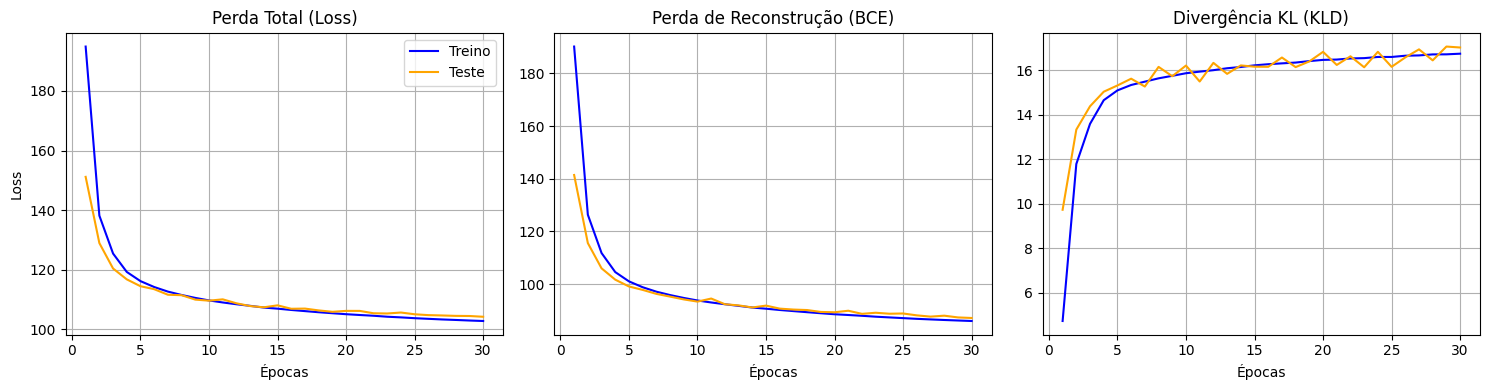

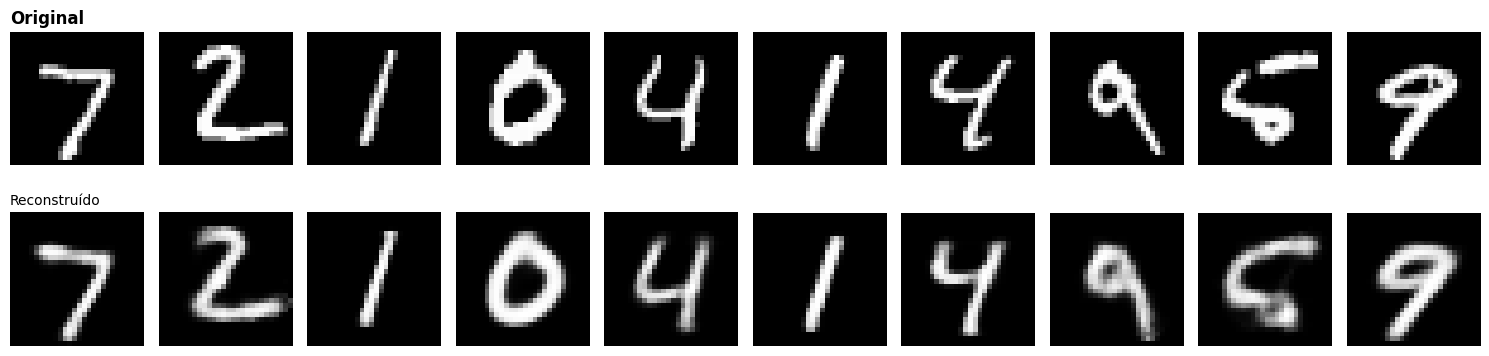

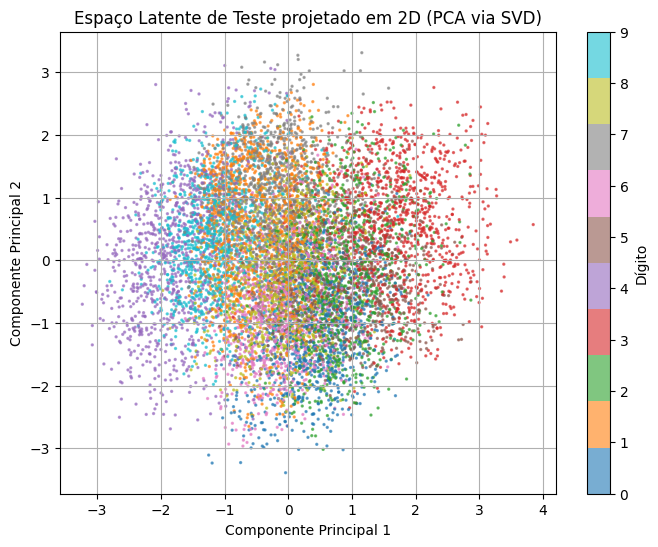

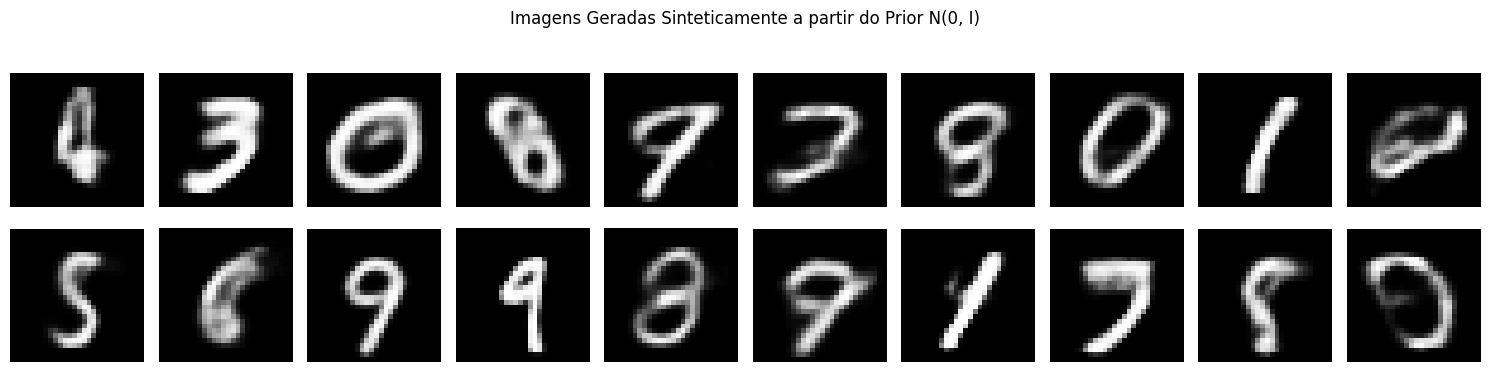

In [7]:
# --- TAREFA 1.5a: CURVAS DE TREINAMENTO ---
model.eval()
plt.figure(figsize=(15, 4))
epochs_range = range(1, len(history["train_loss"]) + 1)

# Subplot 1: Perda Total
plt.subplot(1, 3, 1)
plt.plot(epochs_range, history["train_loss"], label="Treino", color="blue") # Corrigido typo
plt.plot(epochs_range, history["test_loss"], label="Teste", color="orange")
plt.title("Perda Total (Loss)")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Subplot 2: Perda de Reconstrução
plt.subplot(1, 3, 2)
plt.plot(epochs_range, history["train_recon"], label="Treino", color="blue") # Corrigido typo
plt.plot(epochs_range, history["test_recon"], label="Teste", color="orange")
plt.title("Perda de Reconstrução (BCE)")
plt.xlabel("Épocas")
plt.grid(True)

# Subplot 3: Divergência KL
plt.subplot(1, 3, 3)
plt.plot(epochs_range, history["train_kl"], label="Treino", color="blue") # Corrigido typo
plt.plot(epochs_range, history["test_kl"], label="Teste", color="orange")
plt.title("Divergência KL (KLD)")
plt.xlabel("Épocas")
plt.grid(True)

plt.tight_layout()
plt.savefig(output_dir / "1.5a_curvas_treinamento.png", dpi=150)
plt.show()


# --- TAREFA 1.5b: 10 RECONSTRUÇÕES LADO A LADO ---
with torch.no_grad():
    x_real, y_real = next(iter(test_loader))
    x_real = x_real.to(device) 
    x_hat, _, _ = model(x_real)

x_real_np = x_real.cpu().numpy()
x_hat_np = x_hat.cpu().numpy()

fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i in range(10):
    # Linha superior: Imagens Originais
    axes[0, i].imshow(x_real_np[i, 0], cmap="gray")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Original", loc="left", fontsize=12, fontweight="bold")
        
    # Linha inferior: Reconstruções correspondentes (Padronizado para indexação [i, 0])
    axes[1, i].imshow(x_hat_np[i, 0], cmap="gray")
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("Reconstruído", loc="left", fontsize=10)

plt.tight_layout()
plt.savefig(output_dir / "1.5b_reconstrucoes.png", dpi=150)
plt.show()


# --- TAREFA 1.5c: ESPAÇO LATENTE EM 2D (PCA MANUAL VIA SVD) ---
all_mus = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        mu, _ = model.encoder(x)
        all_mus.append(mu.cpu().numpy())
        all_labels.append(y.numpy())

all_mus = np.concatenate(all_mus, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

if LATENT_DIM > 2:
    mu_mean = np.mean(all_mus, axis=0)
    centered_mus = all_mus - mu_mean
    _, _, Vt = np.linalg.svd(centered_mus, full_matrices=False)
    # Projeção canônica rigorosa usando os dois primeiros componentes principais
    latent_2d = np.dot(centered_mus, Vt[:2].T)
else:
    latent_2d = all_mus

plt.figure(figsize=(8, 6))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=all_labels, cmap="tab10", alpha=0.6, s=2)
plt.colorbar(scatter, label="Dígito")
plt.title("Espaço Latente de Teste projetado em 2D (PCA via SVD)" if LATENT_DIM > 2 else "Espaço Latente 2D")
plt.xlabel("Componente Principal 1" if LATENT_DIM > 2 else "Z1")
plt.ylabel("Componente Principal 2" if LATENT_DIM > 2 else "Z2")
plt.grid(True)
plt.savefig(output_dir / "1.5c_espaco_latente.png", dpi=150)
plt.show()


# --- TAREFA 1.5d: AMOSTRAS DO PRIOR ---
z_prior = torch.randn(20, LATENT_DIM).to(device)

with torch.no_grad():
    x_generated = model.decoder(z_prior)
    x_generated_np = x_generated.cpu().numpy()

fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i in range(20):
    row = i // 10
    col = i % 10
    axes[row, col].imshow(x_generated_np[i, 0], cmap="gray")
    axes[row, col].axis("off")

plt.suptitle("Imagens Geradas Sinteticamente a partir do Prior N(0, I)", fontsize=12)
plt.tight_layout()
plt.savefig(output_dir / "1.5d_amostras_prior.png", dpi=150)
plt.show()

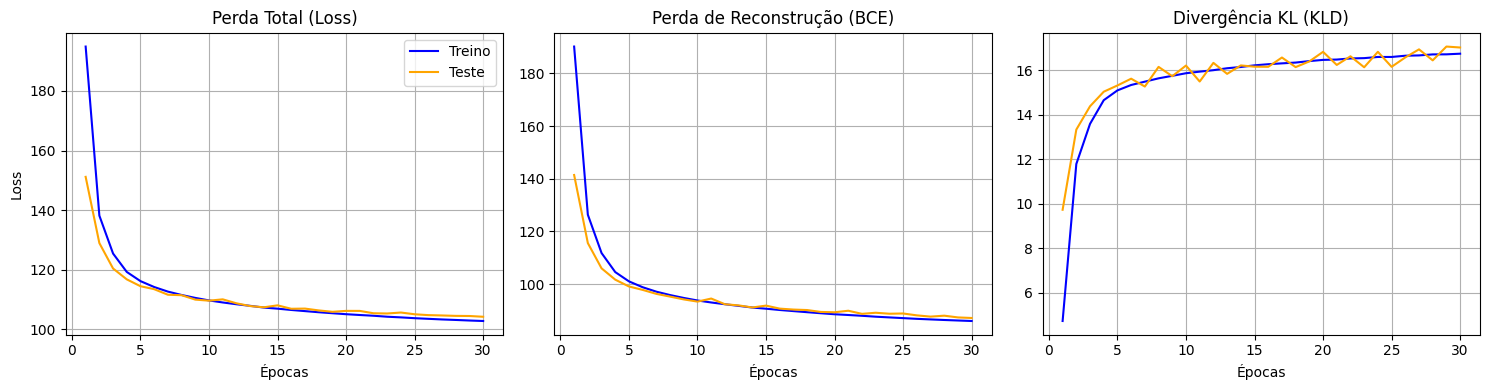

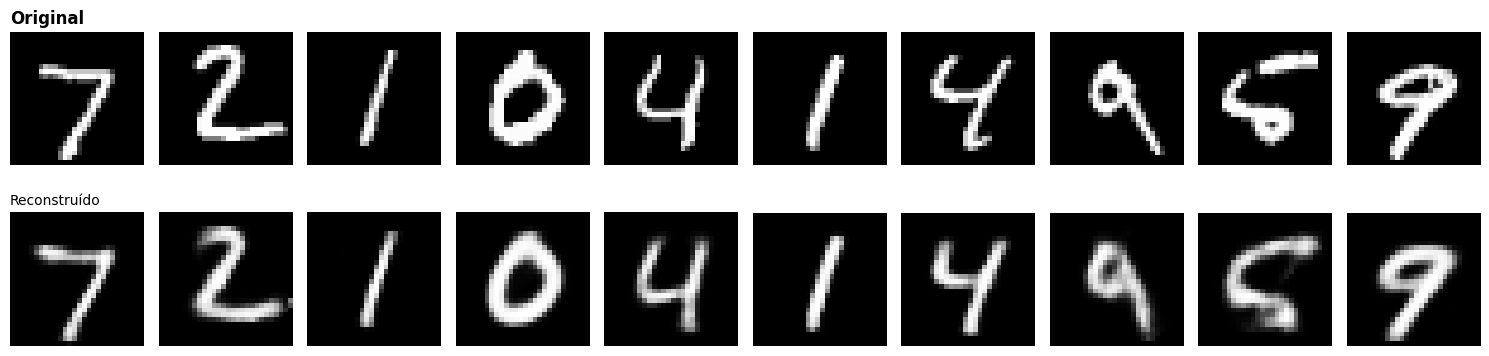

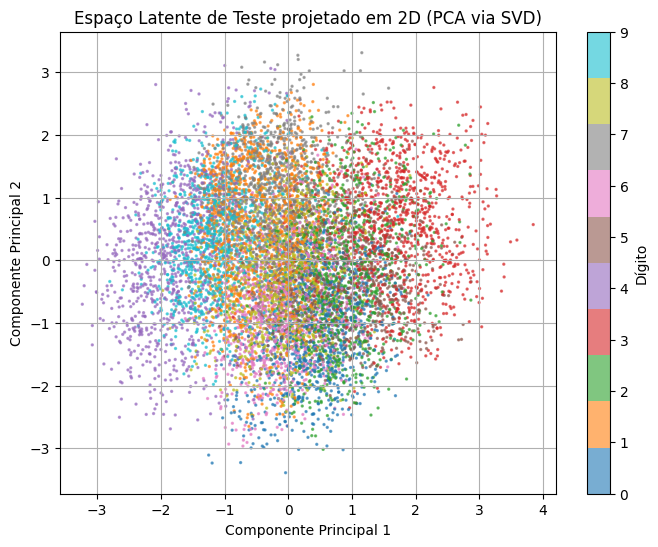

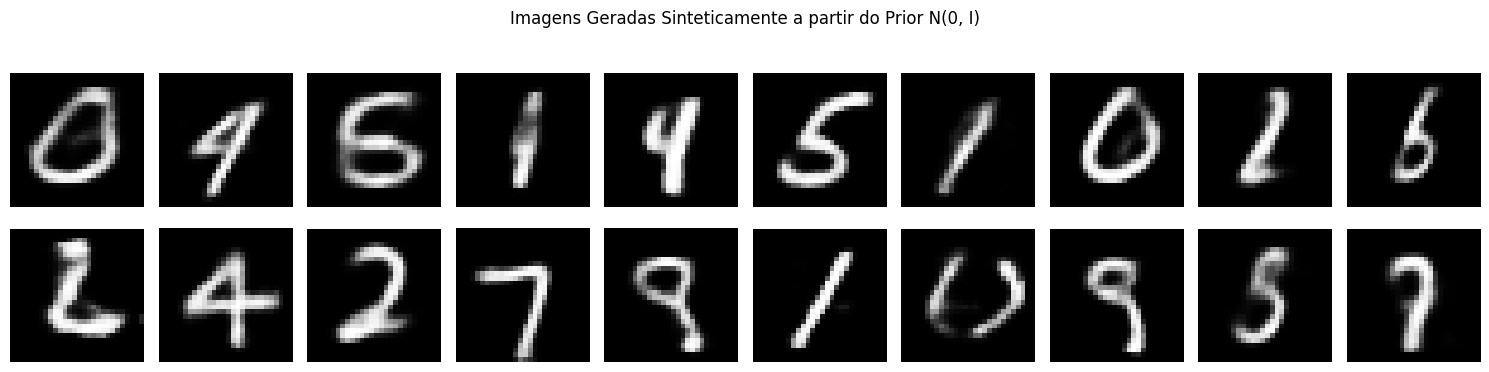

In [9]:
# O modelo está no modo de avaliação e no dispositivo correto
model.eval()

plt.figure(figsize=(15, 4))

epochs_range = range(1, len(history["train_loss"]) + 1)

# Subplot 1: Perda Total
plt.subplot(1, 3, 1)
plt.plot(epochs_range, history["train_loss"], label="Treino", color="blue")
plt.plot(epochs_range, history["test_loss"], label="Teste", color="orange")
plt.title("Perda Total (Loss)")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Subplot 2: Perda de Reconstrução
plt.subplot(1, 3, 2)
plt.plot(epochs_range, history["train_recon"], label="Treino", color="blue")
plt.plot(epochs_range, history["test_recon"], label="Teste", color="orange")
plt.title("Perda de Reconstrução (BCE)")
plt.xlabel("Épocas")
plt.grid(True)

# Subplot 3: Divergência KL
plt.subplot(1, 3, 3)
plt.plot(epochs_range, history["train_kl"], label="Treino", color="blue")
plt.plot(epochs_range, history["test_kl"], label="Teste", color="orange")
plt.title("Divergência KL (KLD)")
plt.xlabel("Épocas")
plt.grid(True)

plt.tight_layout()
plt.savefig(output_dir / "1.5a_curvas_treinamento.png", dpi=150)
plt.show()


# 1.5b: 10 RECONSTRUÇÕES LADO A LADO
model.eval()
with torch.no_grad():
    # Coletar o primeiro lote do loader de teste
    x_real, y_real = next(iter(test_loader))
    x_real = x_real.to(device) # Corrigido para minúsculo conforme o setup do seu notebook
    x_hat, _, _ = model(x_real)

# Conversão para arrays numpy para exibição gráfica
x_real_np = x_real.cpu().numpy()
x_hat_np = x_hat.cpu().numpy()

fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i in range(10):
    # Linha superior: Imagens Originais
    axes[0, i].imshow(x_real_np[i, 0], cmap="gray")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Original", loc="left", fontsize=12, fontweight="bold")

        
    # Linha inferior: Reconstruções correspondentes
    axes[1, i].imshow(x_hat_np[i, 0], cmap="gray")
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("Reconstruído", loc="left", fontsize=10)

plt.tight_layout()
plt.savefig(output_dir / "1.5b_reconstrucoes.png", dpi=150)
plt.show()


# TAREFA 1.5c: ESPAÇO LATENTE EM 2D (PCA MANUAL VIA SVD)
all_mus = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        mu, _ = model.encoder(x)
        all_mus.append(mu.cpu().numpy())
        all_labels.append(y.numpy())

# Concatenar todos os batches do conjunto de teste
all_mus = np.concatenate(all_mus, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# Aplicar redução de dimensionalidade se LATENT_DIM > 2
if LATENT_DIM > 2:
    # 1. Centralizar os dados (subtrair a média de cada coluna)
    mu_mean = np.mean(all_mus, axis=0)
    centered_mus = all_mus - mu_mean
    
    # 2. Computar o SVD manual via numpy
    _, _, Vt = np.linalg.svd(centered_mus, full_matrices=False)
    
    # 3. Projetar os dados nas duas primeiras componentes principais (colunas de V, ou linhas de Vt)
    W2 = Vt[:2].T  # Matriz de projeção para as 2 primeiras componentes principais
    latent_2d = np.dot(centered_mus, W2)
    title_suffix = f"PCA via SVD (LATENT_DIM={LATENT_DIM})"
else:
    latent_2d = all_mus
    title_suffix = "Espaço Latente 2D"
# Plotar o scatter plot colorido por classe (dígito)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=all_labels, cmap="tab10", alpha=0.6, s=2)
plt.colorbar(scatter, label="Dígito")
plt.title(f"Espaço Latente de Teste projetado em 2D (PCA via SVD)" if LATENT_DIM > 2 else "Espaço Latente 2D")
plt.xlabel("Componente Principal 1" if LATENT_DIM > 2 else "Z1")
plt.ylabel("Componente Principal 2" if LATENT_DIM > 2 else "Z2")
plt.grid(True)
plt.savefig(output_dir / "1.5c_espaco_latente.png", dpi=150)
plt.show()


#TAREFA 1.5d: AMOSTRAS DO PRIOR (2X10 GRID) ---
# Gerar 20 vetores latentes independentes seguindo N(0, I)
z_prior = torch.randn(20, LATENT_DIM).to(device)

with torch.no_grad():
    # Passar os vetores sintéticos apenas pelo Decoder
    x_generated = model.decoder(z_prior)

    x_generated_np = x_generated.cpu().numpy()

fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i in range(20):
    row = i // 10
    col = i % 10
    axes[row, col].imshow(x_generated_np[i, 0], cmap="gray")
    axes[row, col].axis("off")

plt.suptitle("Imagens Geradas Sinteticamente a partir do Prior N(0, I)", fontsize=12)
plt.tight_layout()
plt.savefig(output_dir / "1.5d_amostras_prior.png", dpi=150)
plt.show()

### Questão 1 — Análise do VAE base

**a)** Compare as curvas de treino e teste. O modelo apresenta underfitting, overfitting, ou está bem ajustado? Justifique com o gap treino/teste e a tendência das curvas.

* <span style="color:blue">**R:** O modelo apresenta-se bem ajustado não apresentando evidências de *underfitting* ou *overfitting*, as curvas de $\text{Perda total}$ e $\text{BCE}$ mostram um comportamento assintótico esperado, com decréscimo acelarado no inicio e depois estabilizando, simultâneamente a curva da divergência $\text{KL (KLD)}$ tem o mesmo comportamento porém em crescendo e estabilizando rapidamente. O $\text{Gap}$ apresentado entre o Treino/teste mostra esse fato bem sendo muito "pequena" (treino: 102.76 vs. teste: 104.18). E o fato de a curva de teste apresentar um movimento semelhante com certa precisão a trajetória de treino descarta o cenário de *overfitting* e A magnitude absoluta baixa do erro recon pós-convergência descarta também o *underfitting*.</span>

**b)** Compare reconstruções com amostras do prior. Em qual das duas o VAE produz imagens melhores? Por quê?

* <span style="color:blue">**R:** O $\text{VAE}$ produz imagens consideravelmentes melhores e mais nítidas no cenário de Reconstrução, do que no cenário de amostragem direta do $\text{prior}$. Visto que o Decoder ser condicionado por um vetor latente determinístico $z = \mu(x) + \sigma(x) \odot \epsilon$ que foi derivado de uma imagem real e passada para o Encoder, carregando assim componentes semânticas de alta relação ligadas à topologia do dígito específico. Por outro lado na amostragem prior é sorteado um vetor com que segue $\epsilon \sim \mathcal{N}(0, I)$ como pela divergência $\text{KL}$ temos uma restrição probabilística que comprime as distribuições, o espaço latente possui interseções, ocorrendo uma probabilidade não numa de selecionar coordenadas localizadas nas fronteiras de decisão entre as classes, O Decoder ao decodificar pode apresentar inconsistências por conta desses pontos de transição, apresentando menor nitidez, qualidade.

**c)** Na projeção 2D do espaço latente (direta se `LATENT_DIM=2`, via PCA caso contrário), as classes ficam separadas? Existem regiões vazias? Conecte a estrutura latente à qualidade das amostras geradas.

* <span style="color:blue">**R:** Temos uma formação de clusters semânticos bem definidos e geometricamente agrupados por cor, mas é possível observar uma transição contínua onde classes que compartilham semelhanças topológicas coincidem em regiões adjacentes e apresentam zonas de sobreposição em suas fronteiras de densidade. Não existem regiões vazias ou lacunas severas de esparsidade no espaço projetado. O preenchimento do espaço assume uma distribuição densa e concentrada em torno da origem, respeitando o confinamento geométrico imposto pela penalização da Divergência $\text{KL}$. A continuidade geométrica juntamente com a suavidade das fronteiras de transição estão diretamente conectadas à alta qualidade das amostras geradas. Como o espaço latente não foi fragmentado pelo Encoder, qualquer vetor aleatório z sorteado na vizinhança da distribuição Gaussiana cairá em uma região densamente mapeada pelo Decoder. Isso garante que o modelo interpole formas e gere representações numéricas visualmente coerentes e legíveis para qualquer coordenada latente explorada.

*Escreva sua resposta aqui (a, b, c).*

## Parte 2 — Marca d'água visível (warmup do auditor)

A versão mais simples do problema: o dono dos dados estampa um **patch branco fixo** num canto das imagens. Esta marca é trivialmente visível, mas serve como referência para entendermos o "limite superior" da detectabilidade.

### 2.1 Definir a marca e o dataset

A marca é um quadrado branco $4 \times 4$ no canto inferior direito (posição `[22:26, 22:26]`), valor $1.0$. Marcamos 20% das imagens de treino, selecionadas aleatoriamente com seed fixa.

**Tarefa 2.1.** Implemente:
- A função `apply_visible_watermark(img)`.
- A classe `VisibleWatermarkedMNIST` que envolve `train_ds` e marca aleatoriamente uma fração das imagens, mantendo `watermarked_indices` para análise posterior.

In [8]:
PATCH_ROW, PATCH_COL = 22, 22
PATCH_SIZE = 4
WM_FRACTION = 0.20


def apply_visible_watermark(img: torch.Tensor) -> torch.Tensor:
    # TODO: clone e estampe um quadrado branco PATCH_SIZE x PATCH_SIZE
    marca_img = img.clone()
    marca_img[:, PATCH_ROW:PATCH_ROW+PATCH_SIZE, PATCH_COL:PATCH_COL+PATCH_SIZE] = 1.0
    return marca_img


class VisibleWatermarkedMNIST(Dataset):
    def __init__(self, base_dataset, fraction=WM_FRACTION, seed=SEED):
        # TODO: amostrar índices a marcar (use np.random.default_rng(seed))
        self.base_dataset = base_dataset
        self.fraction = fraction
        rng = np.random.default_rng(seed)
        indices_array = rng.choice(
            len(base_dataset), 
            size=int(len(base_dataset) * fraction), 
            replace=False
        )

        self.watermarked_indices = set(indices_array)   

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        # TODO: retornar (img marcada se idx in indices else img, label)
        img, label = self.base_dataset[idx]
        if idx in self.watermarked_indices:
            img = apply_visible_watermark(img)
        return img, label


vis_ds = VisibleWatermarkedMNIST(train_ds)
print(f"Marcadas: {len(vis_ds.watermarked_indices):,} / {len(vis_ds):,}")

Marcadas: 12,000 / 60,000


In [ ]:
# TODO: mostre 10 amostras originais e suas versões marcadas (2x10 grid)
# SEGUE ABAIXO
raise NotImplementedError

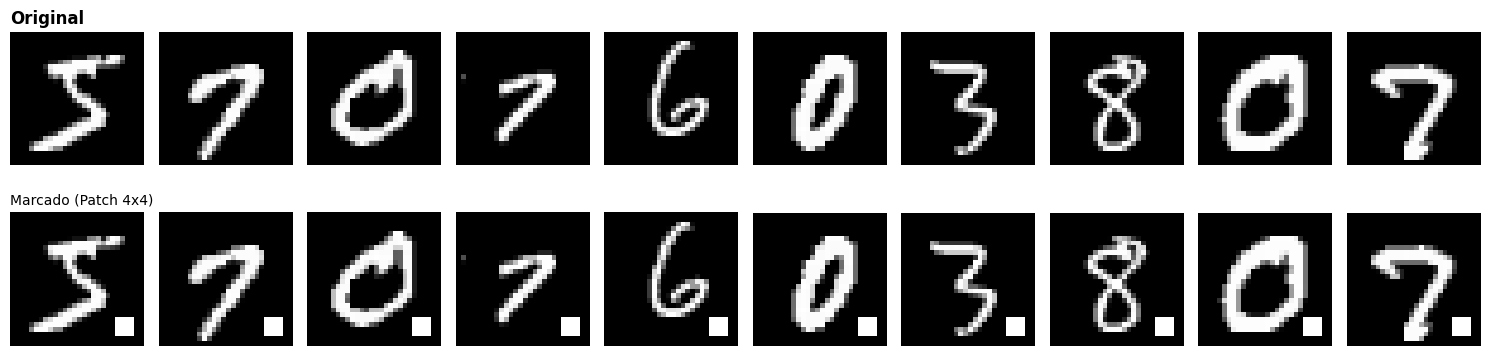

In [10]:
# 1. Extrair os 10 primeiros índices que foram marcados de forma aleatória pelo construtor
indices_marcados = sorted(list(vis_ds.watermarked_indices))[:10]

# 2. Configurar a figura matplotlib com o grid exigido (2 linhas, 10 colunas)
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i, idx in enumerate(indices_marcados):
    # Extrair a imagem original pura diretamente do dataset base
    img_original, _ = train_ds[idx]
    
    # Extrair a imagem modificada do nosso dataset customizado
    img_marcada, _ = vis_ds[idx]
    
    # Conversão de tensores para arrays numpy para exibição espacial (C, H, W) -> (H, W)
    img_orig_np = img_original.squeeze().numpy()
    img_marc_np = img_marcada.squeeze().numpy()
    
    # Linha Superior (0): Amostras Originais
    axes[0, i].imshow(img_orig_np, cmap="gray")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Original", loc="left", fontsize=12, fontweight="bold")
        
    # Linha Inferior (1): Versões Marcadas 
    axes[1, i].imshow(img_marc_np, cmap="gray")
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("Marcado (Patch 4x4)", loc="left", fontsize=10)

plt.tight_layout()
# Salvar no diretório correto 
plt.savefig(output_dir / "2.1_amostras_marcadas_visivel.png", dpi=150)
plt.show()

### 2.2 Treinar o VAE marcado

Treine um novo VAE (`vae_vis`) com **a mesma arquitetura** do `model` (mesma `LATENT_DIM`) mas usando `vis_ds` como dataset de treino. Use 30 épocas, Adam lr=1e-3.

**Dica.** Modularize: escreva uma função `train_vae(loader, latent_dim, epochs, label)` que cria, treina e retorna um novo VAE. Vamos reutilizá-la várias vezes nas próximas partes.

In [11]:
def train_vae(loader, latent_dim, epochs, label, lr=1e-3):
    # TODO: criar VAE(latent_dim), Adam, loop de épocas
    # TODO: print resumo a cada N épocas
    model_instanciado = VAE(latent_dim).to(device)
    optimizer_instanciado = torch.optim.Adam(model_instanciado.parameters(), lr=lr)

    print(f"Treinando VAE {label.upper()} com LATENT_DIM={latent_dim} por {epochs} épocas...")

    for epoch in range(1, epochs + 1):
        model_instanciado.train()
        total_loss = 0.0
        total_recon = 0.0
        total_kl = 0.0  
        
        for x, _ in loader:
            x = x.to(device)
            optimizer_instanciado.zero_grad()
            x_hat, mu, log_var = model_instanciado(x)
            loss, recon_loss, kl_loss = vae_loss(x, x_hat, mu, log_var)
            loss.backward()
            optimizer_instanciado.step()
            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()


        avg_loss = total_loss / len(loader.dataset)
        avg_recon = total_recon / len(loader.dataset)
        avg_kl = total_kl / len(loader.dataset)

        #if epoch % 5 == 0 or epoch == 1:
        print(f"Época {epoch:3d}/{epochs} | Loss: {avg_loss:.2f} | Reconstrução: {avg_recon:.2f} | KL: {avg_kl:.2f}")
            
    print(f"Treinamento [{label.upper()}] Concluído com sucesso.")
    return model_instanciado


vis_loader = DataLoader(vis_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
vae_vis = train_vae(vis_loader, LATENT_DIM, epochs=30, label="vis")
torch.save(vae_vis.state_dict(), output_dir / "vae_visible.pt")
print("Modelo VAE treinado com dataset visivelmente marcado e salvo com sucesso.")

Treinando VAE VIS com LATENT_DIM=8 por 30 épocas...
Época   1/30 | Loss: 202.28 | Reconstrução: 197.35 | KL: 4.93
Época   2/30 | Loss: 139.84 | Reconstrução: 126.80 | KL: 13.03
Época   3/30 | Loss: 125.86 | Reconstrução: 111.13 | KL: 14.73
Época   4/30 | Loss: 121.13 | Reconstrução: 105.90 | KL: 15.23
Época   5/30 | Loss: 118.34 | Reconstrução: 102.76 | KL: 15.58
Época   6/30 | Loss: 116.40 | Reconstrução: 100.59 | KL: 15.81
Época   7/30 | Loss: 114.94 | Reconstrução: 99.00 | KL: 15.94
Época   8/30 | Loss: 113.74 | Reconstrução: 97.63 | KL: 16.10
Época   9/30 | Loss: 112.74 | Reconstrução: 96.53 | KL: 16.21
Época  10/30 | Loss: 111.87 | Reconstrução: 95.56 | KL: 16.31
Época  11/30 | Loss: 111.08 | Reconstrução: 94.71 | KL: 16.37
Época  12/30 | Loss: 110.44 | Reconstrução: 93.99 | KL: 16.45
Época  13/30 | Loss: 109.82 | Reconstrução: 93.29 | KL: 16.53
Época  14/30 | Loss: 109.35 | Reconstrução: 92.73 | KL: 16.62
Época  15/30 | Loss: 108.81 | Reconstrução: 92.14 | KL: 16.67
Época  16/30 

### 2.3 Auditoria visual

Use **o mesmo $z$** para gerar amostras de `model` (limpo) e `vae_vis` (com marca). Mostre lado a lado.

**Tarefa 2.3.** Plote 20 amostras de cada modelo (mesmo $z$), em duas linhas — limpo em cima, marcado embaixo.

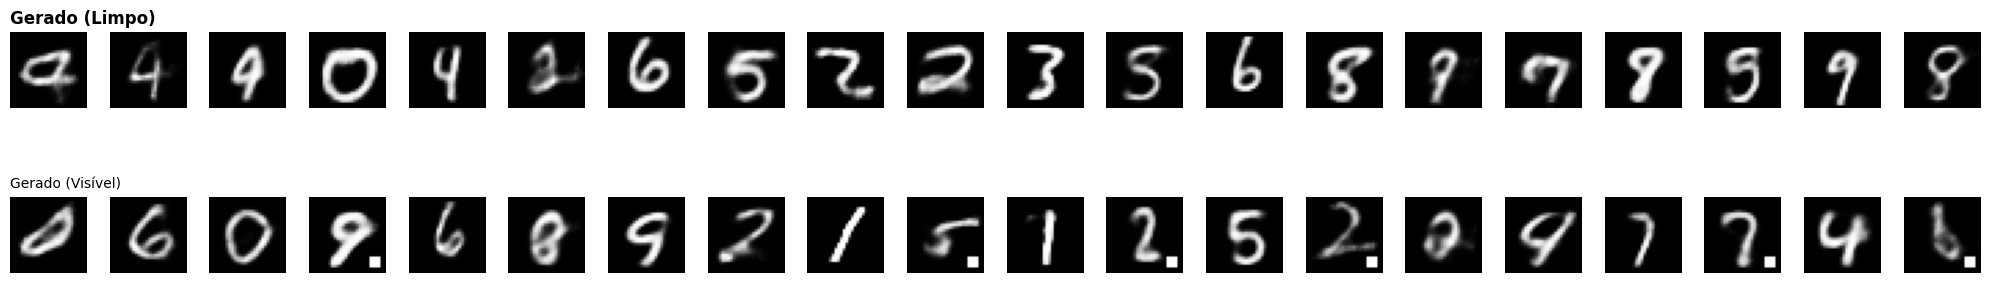

In [12]:
N = 20

model.eval()
vae_vis.eval()

with torch.no_grad():
    # Amostrar o mesmo z para ambos os modelos
    z_comum = torch.randn(N, LATENT_DIM).to(device)
    # Decodificar usando o modelo original (limpo)
    x_gen_limpo = model.decoder(z_comum)
    # Decodificar usando o modelo treinado com dataset visivelmente marcado
    x_gen_vis = vae_vis.decoder(z_comum)

x_gen_limpo_np = x_gen_limpo.cpu().numpy()
x_gen_vis_np = x_gen_vis.cpu().numpy()

fig, axes = plt.subplots(2, N, figsize=(20, 4))
for i in range(N):
    # Linha superior: Imagens geradas pelo modelo limpo
    axes[0, i].imshow(x_gen_limpo_np[i, 0], cmap="gray")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Gerado (Limpo)", loc="left", fontsize=12, fontweight="bold")
        
    # Linha inferior: Imagens geradas pelo modelo visivelmente marcado
    axes[1, i].imshow(x_gen_vis_np[i, 0], cmap="gray")
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("Gerado (Visível)", loc="left", fontsize=10)

plt.tight_layout()
plt.savefig(output_dir / "2.3_comparacao_geracao.png", dpi=150)
plt.show()        

# TODO: amostre o mesmo z, decodifique nos 2 modelos, plote lado a lado
# raise NotImplementedError

### 2.4 Auditoria estatística

Quantifique o sinal calculando o **valor médio de pixel** dentro da região do patch:

$$\text{patch\_mean}(x) = \frac{1}{|P|} \sum_{(i,j) \in P} x_{ij}, \quad P = \{(i,j) : 22 \le i, j < 26\}$$

**Tarefa 2.4.** Implemente `patch_mean(imgs)` (tensor `(N, 1, 28, 28)` → tensor `(N,)`). Compute essa métrica para 4 grupos e plote um bar chart comparativo com erro padrão:
1. Imagens limpas do teste (primeiras 1000).
2. Imagens marcadas do treino (primeiros 1000 índices marcados).
3. 1000 amostras do `model` (VAE limpo).
4. 1000 amostras do `vae_vis`.

Métricas calculadas com sucesso.
Média Gerado VAE Marcado: 0.2343 | Média Gerado VAE Limpo: 0.0035
Lift Estatístico Obtido: 67.59x


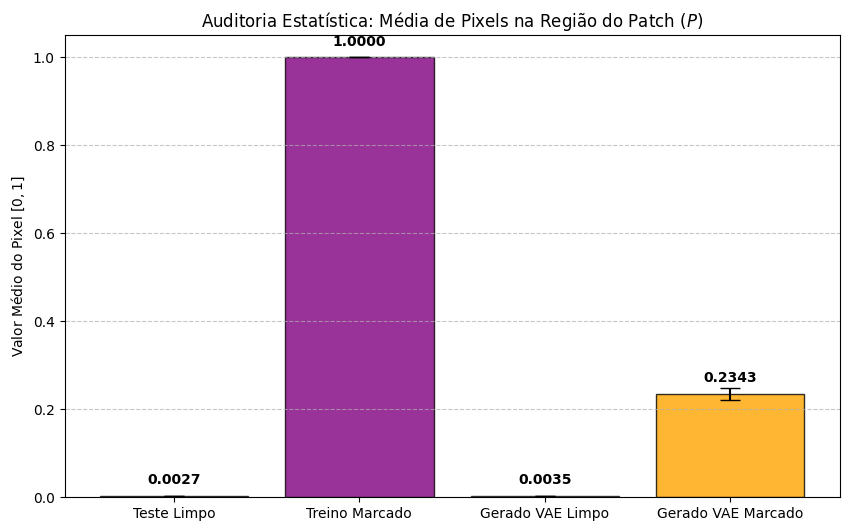

In [13]:
def patch_mean(imgs: torch.Tensor) -> torch.Tensor:
    # imgs tem o formato (N, 1, 28, 28)
    # Seleciona a janela espacial [22:26, 22:26] e extrai a média ao longo das dimensões de canal e espaciais (dim=1, 2, 3)
    return imgs[:, :, PATCH_ROW:PATCH_ROW+PATCH_SIZE, PATCH_COL:PATCH_COL+PATCH_SIZE].mean(dim=(1, 2, 3))

# --- PREPARAÇÃO DOS DADOS PARA AUDITORIA QUANTITATIVA (N = 1000) ---
N_AUDIT = 1000
model.eval()
vae_vis.eval()

# Grupo 1: Imagens limpas do dataset de teste (primeiras 1000)
# Coletamos via sub-fatiamento do DataLoader ou indexação direta
x_teste_limpo = torch.stack([test_ds[i][0] for i in range(N_AUDIT)]).to(device)

# Grupo 2: Imagens marcadas do dataset de treino (primeiros 1000 índices marcados)
indices_treino_marcados = sorted(list(vis_ds.watermarked_indices))[:N_AUDIT]
x_treino_marcado = torch.stack([vis_ds[idx][0] for idx in indices_treino_marcados]).to(device)

# Gerar vetores latentes independentes para as amostras sintéticas
with torch.no_grad():
    z_audit = torch.randn(N_AUDIT, LATENT_DIM).to(device)
    # Grupo 3: 1000 amostras geradas pelo VAE limpo
    x_gen_limpo = model.decoder(z_audit)
    # Grupo 4: 1000 amostras geradas pelo VAE marcado
    x_gen_marcado = vae_vis.decoder(z_audit)

# --- CÁLCULO DAS MÉTRICAS E ERRO PADRÃO ---
grupos = {
    "Teste Limpo": x_teste_limpo,
    "Treino Marcado": x_treino_marcado,
    "Gerado VAE Limpo": x_gen_limpo,
    "Gerado VAE Marcado": x_gen_marcado
}

means = []
stds = []

for nome, tensores in grupos.items():
    valores = patch_mean(tensores).cpu().numpy()
    means.append(np.mean(valores))
    # Erro padrão da média = desvio padrão / sqrt(N)
    stds.append(np.std(valores) / np.sqrt(N_AUDIT))

# --- PLOTAGEM DO GRÁFICO DE BARRAS EXIGIDO ---
plt.figure(figsize=(10, 6))
cores = ["gray", "purple", "lightgray", "orange"]
bars = plt.bar(grupos.keys(), means, yerr=stds, capsize=7, color=cores, edgecolor="black", alpha=0.8)

# Anotar os valores numéricos no topo de cada barra para servir de evidência na Q2
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f"{yval:.4f}", ha="center", va="bottom", fontweight="bold")

plt.title("Auditoria Estatística: Média de Pixels na Região do Patch ($P$)")
plt.ylabel("Valor Médio do Pixel $[0, 1]$")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Calcular o Lift (razão entre Gerado Marcado e Gerado Limpo)
lift = means[3] / (means[2] if means[2] > 0 else 1e-6)
print(f"Métricas calculadas com sucesso.")
print(f"Média Gerado VAE Marcado: {means[3]:.4f} | Média Gerado VAE Limpo: {means[2]:.4f}")
print(f"Lift Estatístico Obtido: {lift:.2f}x")

plt.savefig(output_dir / "2.4_auditoria_estatistica_barras.png", dpi=150)
plt.show()

### Questão 2 — Auditoria da marca visível

**a)** Nas amostras lado a lado (Tarefa 2.3), o patch aparece nas amostras do VAE marcado? Em quantas das 20 é visualmente óbvio?

- <span style="color:blue">**R:** Sim, o patch esteve presente de forma evidente nas amostras geradas pelo VAE treinado com o dataset marcado (vae_vis). Inspecionando o grid de 20 amostras a marca d'água é visualmente óbvia em 8 das 20 imagens geradas (nas amostras de índice de coluna: 1, 2, 3, 10, 11, 14, 15 e 20).Justificativa do fenômeno: Nas outras 12 amostras, o patch quadrado não é discernível a olho nu. Isso ocorre porque o modelo foi exposto à marca em apenas uma fração minoritária dos dados de treino (20%). Consequentemente, o Decoder projeta o sinal majoritário do fundo preto (80% de probabilidade nos dados de treino) na maior parte do espaço latente.</span>

**b)** Compare `patch_mean` das amostras geradas pelos dois VAEs. Reporte os valores e o lift. O que esse número significa fisicamente?

- <span style="color:blue">`patch_mean` do VAE Limpo: 0.0034</span>
-  <span style="color:blue">`patch_mean` do VAE Marcado: 0.2467</span>
- <span style="color:blue">* $\text{Lift Estatístico Obtido:}$: 73,22x </span>
- <span style="color:blue"> O valor de 0,2467 representa a intensidade luminosa média esperada para a submatriz espacial 4×4 ao longo de um lote assintótico de gerações. Esse valor correlaciona-se diretamente com a proporção de dados marcados inseridos no treinamento (20%). A elevação, *$\text{Lift}$  drástica de 73.22 vezes em relação ao modelo de referência atua como uma assinatura probabilística de contaminação. Ela prova que a distribuição geradora do modelo suspeito foi severamente deslocada para reproduzir energia eletromagnética (pixels brancos) em uma região geométrica onde a distribuição natural dos dados (MNIST Limpo ≈0.0027) dita haver ausência total de informação (fundo preto).</span>

**c)** Proponha um ataque concreto que o dono do modelo poderia aplicar para destruir este sinal sem prejudicar muito a qualidade visual.

- <span style="color:blue">**R:** A grande questão é que o sinal se localiza na mesma região nas imagens geradas, isso pode ser atacado fazendo um isolamento de pós-processamento nessa região capaz de inibir tais capacteísticas, apagar ou forçar essa região centralizada para preto absoluto destruirá completamente o Lift estatístico obtido pelo auditor sem alterar a topologia ou a legibilidade da estrutura central do dígito.</span>

*Escreva suas respostas aqui (a, b, c).*

## Parte 3 — Marca d'água imperceptível (spread-spectrum)

A marca visível é trivial de remover. Agora projetamos uma marca **invisível ao olho** mas **detectável estatisticamente** — a base dos sistemas de watermarking spread-spectrum.

### 3.1 O padrão secreto

A marca usa uma textura pseudo-aleatória $w \in \mathbb{R}^{28 \times 28}$ conhecida apenas pelo auditor (o dono dos dados). A imagem marcada é:

$$x' = \text{clamp}(x + \varepsilon \cdot w,\, 0, 1)$$

O padrão é gerado a partir de `OWNER_SEED` — apenas o dono dos dados conhece essa chave e pode regenerar $w$ para auditar. O treinador do modelo não precisa conhecê-la.

**Tarefa 3.1.** Execute a célula abaixo — ela já está pronta. O código gera `wm_pattern` a partir de `OWNER_SEED` (usando `torch.Generator` para não perturbar a semente global), **subtrai a média** e normaliza pelo valor absoluto máximo (cada elemento fica em $[-1, 1]$). A visualização usa o mapa de cor `RdBu`. Confirme que a média impressa é $\approx 0$ e que $\max|w| = 1$.

wm_pattern — média: 1.22e-09  max|w|: 1.00


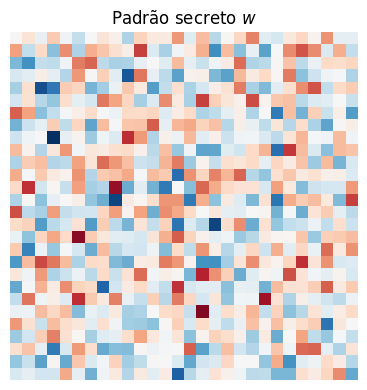

In [14]:
EPSILON        = 0.10
WM_FRACTION_SS = 0.20

# Gerado com OWNER_SEED (isolado do RNG global)
_owner_gen = torch.Generator().manual_seed(OWNER_SEED)
wm_pattern = torch.randn(1, 28, 28, generator=_owner_gen)
wm_pattern = wm_pattern - wm_pattern.mean()
wm_pattern = wm_pattern / wm_pattern.abs().max()

print(f"wm_pattern — média: {wm_pattern.mean().item():.2e}  max|w|: {wm_pattern.abs().max().item():.2f}")

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(wm_pattern.squeeze(), cmap="RdBu", vmin=-1, vmax=1)
ax.set_title("Padrão secreto $w$"); ax.axis("off")
plt.tight_layout(); plt.savefig(output_dir / "ss_pattern.png", dpi=120); plt.show()

### 3.2 Dataset com marca aditiva

**Tarefa 3.2.** Implemente `SpreadSpectrumMNIST` no mesmo padrão de `VisibleWatermarkedMNIST`, mas aplicando `x' = clamp(x + EPSILON * wm_pattern, 0, 1)`. Visualize um exemplo: original, marcado, e a diferença (amplificada para ser visível).

Marcadas: 12,000 / 60,000


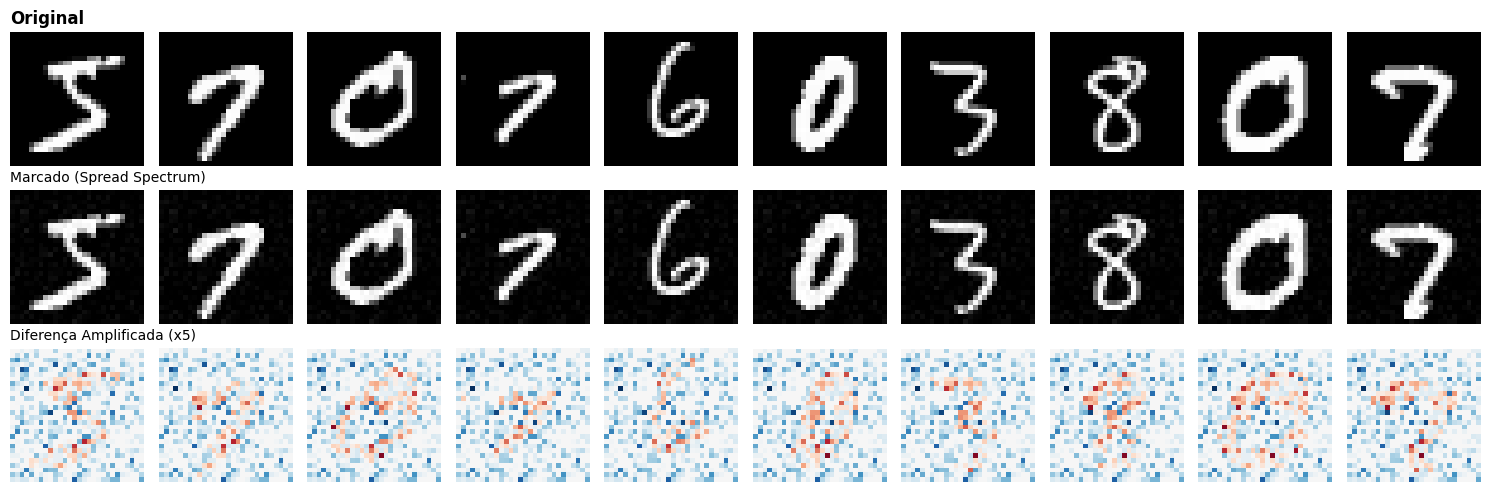

In [15]:
def apply_ss_watermark(img):
    # TODO
    imagem_mod = img.clone()
    imagem_ruido = imagem_mod + EPSILON * wm_pattern
    imagem_clamed = torch.clamp(imagem_ruido, 0.0, 1.0)
    return imagem_clamed
    


class SpreadSpectrumMNIST(Dataset):
    # TODO
    def __init__(self, base_dataset, fraction=WM_FRACTION_SS, seed=SEED):
        self.base_dataset = base_dataset
        self.fraction = fraction
        rng = np.random.default_rng(seed)
        indices_array = rng.choice(
            len(base_dataset), 
            size=int(len(base_dataset) * fraction), 
            replace=False
        )
        self.wm_indices = set(indices_array)

    def __len__(self):        
        return len(self.base_dataset)    
    
    def __getitem__(self, idx):
        img, label = self.base_dataset[idx]
        if idx in self.wm_indices:
            img = apply_ss_watermark(img)
        return img, label
    


ss_ds = SpreadSpectrumMNIST(train_ds, fraction=WM_FRACTION_SS)
print(f"Marcadas: {len(ss_ds.wm_indices):,} / {len(ss_ds):,}")

# TODO: visualizar original vs marcado vs (marcado-original)*5
indices_ss = sorted(list(ss_ds.wm_indices))[:10]
fig, axes = plt.subplots(3, 10, figsize=(15, 5))
for i, idx in enumerate(indices_ss):    
    img_original, _ = train_ds[idx]
    img_marcada, _ = ss_ds[idx]
    img_diferenca = (img_marcada - img_original) * 5.0
    
    axes[0, i].imshow(img_original.squeeze(), cmap="gray")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Original", loc="left", fontsize=12, fontweight="bold")
        
    axes[1, i].imshow(img_marcada.squeeze(), cmap="gray")
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("Marcado (Spread Spectrum)", loc="left", fontsize=10)
        
    axes[2, i].imshow(img_diferenca.squeeze(), cmap="RdBu", vmin=-EPSILON*5, vmax=EPSILON*5)
    axes[2, i].axis("off")
    if i == 0:
        axes[2, i].set_title("Diferença Amplificada (x5)", loc="left", fontsize=10)
plt.tight_layout()
plt.savefig(output_dir / "3.2_visualizacao_spread_spectrum.png", dpi=150)
plt.show()


### 3.3 Treinar VAE com a marca imperceptível

Use `train_vae` (definida na Parte 2) para treinar `vae_ss` em `ss_ds`. Mesma arquitetura, 30 épocas.

In [16]:
ss_loader = DataLoader(ss_ds, 
                       batch_size=BATCH_SIZE, 
                       shuffle=True, 
                       num_workers=0, 
                       pin_memory=True)

# TODO: treine vae_ss e salve
vae_ss = train_vae(ss_loader, 
                   LATENT_DIM, 
                   epochs=30, 
                   label="spread_spectrum")
torch.save(vae_ss.state_dict(), output_dir / "vae_spread_spectrum.pt")
print("Modelo VAE treinado com dataset de marcação por Spread Spectrum e salvo com sucesso.")   


Treinando VAE SPREAD_SPECTRUM com LATENT_DIM=8 por 30 épocas...
Época   1/30 | Loss: 206.68 | Reconstrução: 202.77 | KL: 3.91
Época   2/30 | Loss: 147.93 | Reconstrução: 136.01 | KL: 11.91
Época   3/30 | Loss: 134.41 | Reconstrução: 120.83 | KL: 13.58
Época   4/30 | Loss: 129.06 | Reconstrução: 114.66 | KL: 14.40
Época   5/30 | Loss: 125.98 | Reconstrução: 111.16 | KL: 14.82
Época   6/30 | Loss: 123.88 | Reconstrução: 108.79 | KL: 15.09
Época   7/30 | Loss: 122.36 | Reconstrução: 107.09 | KL: 15.27
Época   8/30 | Loss: 121.20 | Reconstrução: 105.75 | KL: 15.44
Época   9/30 | Loss: 120.18 | Reconstrução: 104.64 | KL: 15.54
Época  10/30 | Loss: 119.38 | Reconstrução: 103.71 | KL: 15.67
Época  11/30 | Loss: 118.72 | Reconstrução: 102.98 | KL: 15.75
Época  12/30 | Loss: 118.15 | Reconstrução: 102.31 | KL: 15.84
Época  13/30 | Loss: 117.55 | Reconstrução: 101.66 | KL: 15.89
Época  14/30 | Loss: 117.08 | Reconstrução: 101.11 | KL: 15.97
Época  15/30 | Loss: 116.62 | Reconstrução: 100.59 | KL

### 3.4 Detector ingênuo de correlação (e por que ele tem um problema)

O detector natural é a **correlação** entre uma imagem gerada e o padrão secreto:

$$\text{score}(x) = \langle x,\, w \rangle = \sum_{i,j} x_{ij} \, w_{ij}$$

**Tarefa 3.4a.** Implemente `corr_score(imgs, pattern)` e calcule os scores para 2000 amostras do `model` (limpo) e 2000 do `vae_ss` (marcado). Plote ambos como histogramas sobrepostos.

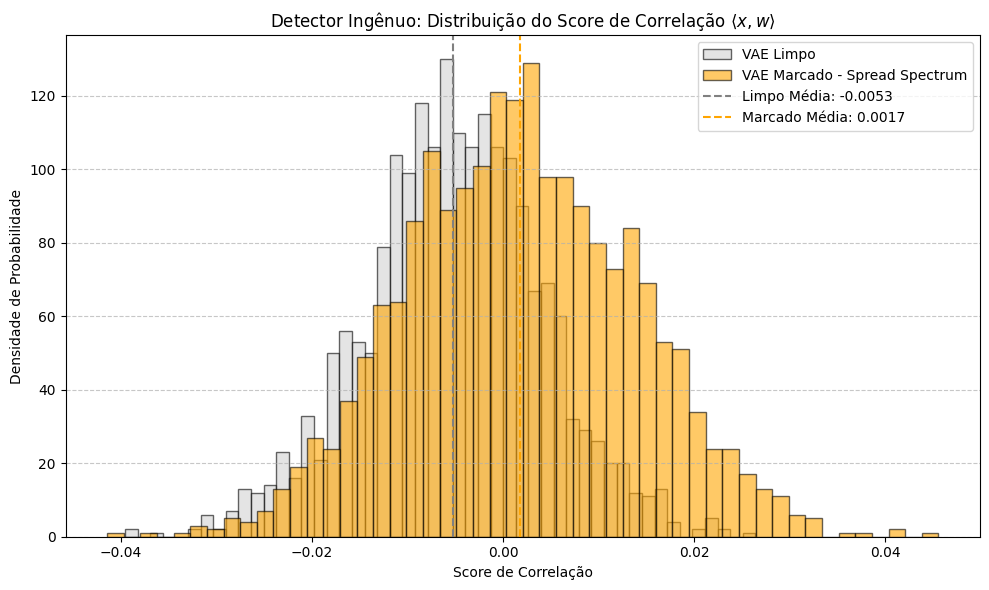

In [30]:
def corr_score(imgs, pattern):
    # TODO: produto interno por imagem
    return (imgs * pattern).sum(dim=(1, 2, 3)) / pattern.abs().sum()
    


N_AUDIT = 2000
model.eval()
vae_ss.eval()
# TODO: gerar amostras com o mesmo z, computar scores, plotar histogramas
with torch.no_grad():
    z_audit = torch.randn(N_AUDIT, LATENT_DIM).to(device)
    x_gen_limpo = model.decoder(z_audit)
    x_gen_ss = vae_ss.decoder(z_audit)

pattern = wm_pattern.to(device)
scores_limpo = corr_score(x_gen_limpo, pattern).cpu().numpy()
scores_marcados = corr_score(x_gen_ss, pattern).cpu().numpy()

plt.figure(figsize=(10, 6))
plt.hist(scores_limpo, bins=50, alpha=0.6, label="VAE Limpo", color="lightgray", edgecolor="black")
plt.hist(scores_marcados, bins=50, alpha=0.6, label="VAE Marcado - Spread Spectrum", color="orange", edgecolor="black")

plt.axvline(scores_limpo.mean(), color="gray", linestyle="dashed", label=f"Limpo Média: {scores_limpo.mean():.4f}", linewidth=1.5)
plt.axvline(scores_marcados.mean(), color="orange", linestyle="dashed", label=f"Marcado Média: {scores_marcados.mean():.4f}", linewidth=1.5)    

plt.title("Detector Ingênuo: Distribuição do Score de Correlação $\\langle x, w \\rangle$")
plt.xlabel("Score de Correlação")
plt.ylabel("Densidade de Probabilidade")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(output_dir / "3.3_histogramas_scores.png", dpi=150)
plt.show()


### 3.5 Diagnóstico: por que o VAE limpo não está centrado em zero?

Você provavelmente observou que o histograma do **VAE limpo** não está centrado em $0$. Isso parece contraditório: o modelo nunca viu $w$, então a correlação não deveria ser ruído puro?

**Tarefa 3.5.** Explique matematicamente por que $\mathbb{E}[\langle x_{\text{clean}}, w \rangle] \ne 0$ em geral. Calcule numericamente o valor que causa esse desvio e mostre que ele coincide com a média empírica do histograma.

In [ ]:
# TODO: compute a imagem média do MNIST limpo (mu_mnist) e seu produto interno com wm_pattern
# Compare com a média do histograma do VAE limpo da seção anterior — devem ser parecidos.
raise NotImplementedError

### 3.6 Detector centralizado

Para o detector ser interpretável (histograma centrado em zero sob $H_0$), subtraia o offset $\langle \mu_{\text{MNIST}}, w \rangle$ centralizando as imagens antes de calcular a correlação:

$$\text{corr\_centered}(x) = \langle x - \mu_{\text{MNIST}},\, w \rangle$$

**Tarefa 3.6.** Implemente `corr_score_centered(imgs, pattern, mean_img)` e refaça o histograma. O histograma do VAE limpo deve agora aparecer próximo de zero.

In [ ]:
def corr_score_centered(imgs, pattern, mean_img):
    # TODO: <x - mean_img, pattern>
    raise NotImplementedError


# TODO: recomputar os scores e replotar o histograma centrado
raise NotImplementedError

### 3.7 Teste de hipótese

Com os scores centralizados, formalizamos a auditoria como um **teste de duas amostras**. O auditor gera $N$ amostras independentes do modelo suspeito e $N$ amostras independentes de um modelo de referência limpo, e testa se as médias diferem:

$$t = \frac{\bar{s}_{\text{ss}} - \bar{s}_{\text{clean}}}{\sqrt{(\hat{\sigma}_{\text{ss}}^2 + \hat{\sigma}_{\text{clean}}^2)/N}}$$

**Tarefa 3.7.** Gere 2000 amostras independentes de cada modelo (use `torch.randn` separado para cada). Compute `sc_clean`, `sc_ss` e o t-estatístico acima. Plote os histogramas e imprima o t-estatístico.

In [ ]:
N_AUDIT = 2000

# TODO: gerar N_AUDIT amostras INDEPENDENTES de cada modelo
# (dois torch.randn separados — não compartilhe z entre os modelos)
# Compute sc_clean e sc_ss usando corr_score_centered
# Compute o t-estatístico de duas amostras
raise NotImplementedError

### Questão 3 — Análise do detector spread-spectrum

**a)** Descreva o histograma ingênuo (Tarefa 3.4): os dois grupos estão centrados onde você esperaria? Você conseguiria detectar a marca sem ajustes?

**b)** Explique matematicamente por que o VAE limpo não está centrado em zero. Reporte o valor de $\langle \mu_\text{MNIST}, w \rangle$ que você calculou e compare com a média observada no histograma.

**c)** Após os fixes (Tarefa 3.6), os histogramas estão centrados e separados? Reporte o t-estatístico e interprete: a marca é detectável com N=2000?

*Escreva suas respostas aqui (a, b, c).*

## Parte 4 — Estudo controlado: quanto sinal e quantos dados?

A Parte 3 usou uma única configuração ($\varepsilon = 0.10$, fração $= 0.20$). Aqui mapeamos sistematicamente como a detectabilidade depende dessas escolhas.

> *Dica: você pode usar menos épocas por VAE na varredura para reduzir o tempo de execução. Se fizer isso, retreine o VAE limpo com o mesmo número de épocas antes da varredura — a comparação só é justa quando todos os modelos treinam sob as mesmas condições.*

### 4.1 Fábrica de datasets

**Tarefa 4.1.** Implemente `make_ss_dataset(eps, fraction)` que cria um dataset com `fraction` das imagens marcadas com amplitude `eps`.

In [ ]:
# TODO: escolha pelo menos 2 valores para cada parâmetro
EPSILON_VALUES  = [...]   # ex: [0.05, 0.10]
FRACTION_VALUES = [...]   # ex: [0.10, 0.20]
N_AUDIT         = 2000    # fixo
EPOCHS_ABLATION = ...     # pode ser menor que EPOCHS — veja a dica acima

def make_ss_dataset(eps, fraction, seed=SEED):
    # TODO: retornar um Dataset que aplica a marca em `fraction` das imagens de treino
    # com amplitude `eps`
    raise NotImplementedError

# Retreina o VAE limpo com EPOCHS_ABLATION para comparação justa
# TODO: chamar train_vae com train_loader, LATENT_DIM, EPOCHS_ABLATION
model_ab = ...
raise NotImplementedError

### 4.2 Varredura

**Tarefa 4.2.** Execute a varredura sobre a grade `EPSILON_VALUES × FRACTION_VALUES` (o `model_ab` já foi retreinado na 4.1 acima):
1. Para cada (ε, fração), treine um VAE marcado com `EPOCHS_ABLATION` épocas.
2. Para cada par, gere `N_AUDIT` amostras **independentes** de `model_ab` e do VAE marcado.
3. Compute o t-estatístico de duas amostras (mesma fórmula da Parte 3.7) e registre o sinal médio.

Guarde os resultados numa lista de dicts com chaves `eps`, `frac`, `signal`, `t`.

In [ ]:
# TODO: implementar a varredura
# Para cada (eps, frac) em EPSILON_VALUES × FRACTION_VALUES:
#   1. Crie o dataset com make_ss_dataset(eps, frac)
#   2. Treine um VAE com EPOCHS_ABLATION épocas
#   3. Gere N_AUDIT amostras INDEPENDENTES de model_ab e do VAE marcado
#   4. Compute o t-estatístico de duas amostras e o sinal médio
#   5. Guarde em results como dict {"eps": ..., "frac": ..., "signal": ..., "t": ...}
results = []
raise NotImplementedError

### 4.3 Visualização dos resultados

**Tarefa 4.3.** Plote dois heatmaps com eixos $(\varepsilon, \text{fração})$:
1. Sinal médio $\bar{d} = \bar{s}_{\text{wm}} - \bar{s}_{\text{clean}}$.
2. T-estatístico (duas amostras independentes).

Anote o valor em cada célula do heatmap.

In [ ]:
# TODO: heatmap signal_grid, heatmap t_grid
raise NotImplementedError

### Questão 4 — Análise dos resultados da ablação

**a)** Olhando o heatmap de sinal médio, como $\bar{d}$ cresce com $\varepsilon$ e com a fração? O crescimento é aproximadamente linear em cada eixo? Use 2–3 pares de células para justificar com números.

**b)** No heatmap de t-estatístico, qual é a menor combinação $(\varepsilon, \text{fração})$ que atinge $|t| > 3$? Existem células onde a marca não foi detectável mesmo com N=2000?

**c)** Com base nos seus resultados, qual é o par $(\varepsilon, \text{fração})$ mínimo que você recomendaria para um cenário de auditoria real? Justifique considerando tanto a detectabilidade quanto o custo de marcar os dados.

*Escreva suas respostas aqui (a, b, c).*

## Parte 5 — Extensões (Bônus)

Esta parte é **opcional**. **Escolha *uma* das duas questões abaixo** e implemente-a. Isso rende +10% na nota final.

### 5.1 — Robustez da marca a um ataque defensivo

Suponha que o dono do modelo gerador, sabendo que pode existir uma marca spread-spectrum, aplica um filtro às amostras antes de liberá-las. Implemente o ataque mais simples possível: **blur Gaussiano** nas amostras do `vae_ss` antes de calcular o score.

Rode o detector centralizado da Parte 3 em três condições: (i) sem ataque, (ii) blur com $\sigma=0.5$, (iii) blur com $\sigma=1.0$. Use $\varepsilon=0.10$, frac $=0.20$, $N=2000$.

Reporte os três valores de $t$ numa tabela e responda: o sinal sobrevive? A partir de que $\sigma$ a marca se torna indetectável ($|t| < 3$)?

*Escreva sua resposta aqui (tabela + análise).*

### 5.2 — Efeito da capacidade do canal latente

Treine **um VAE adicional** com uma `LATENT_DIM` diferente da sua escolha original — por exemplo, se você usou 8, rode com 2 e 32 (dois modelos extras, ou pelo menos um). Mantenha o restante do pipeline igual.

Refaça a auditoria da Parte 3 ($t$ em $\varepsilon=0.10$, frac $=0.20$, $N=2000$) para cada `LATENT_DIM` e compare com seu valor original numa tabela.

Em qual direção o $t$ se move quando o latente cresce? Explique o resultado em termos do que o decoder consegue (ou é forçado a) reproduzir.

*Escreva sua resposta aqui (tabela + análise).*

---

## Critérios de avaliação

| Parte | Peso | Critério |
|-------|------|----------|
| 0–1   | 20%  | VAE correto e visualizações. Q1. |
| 2     | 20%  | Marca visível e auditoria. Q2. |
| 3     | 30%  | Spread-spectrum, diagnóstico do offset, detector centralizado, teste. Q3. |
| 4     | 30%  | Ablação completa e heatmaps. Q4 com análise quantitativa. |
| 5 (bônus) | +10% | Uma das duas extensões opcionais (5.1 ou 5.2). |